In [30]:
import torch
from torch import Tensor
print(torch.__version__)
torch.manual_seed(42)

2.10.0+cpu


In [31]:
# Install required packages.
import os
os.environ['TORCH'] = torch.__version__

!pip install torch-scatter -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-${TORCH}.html
!pip install pyg-lib -f https://data.pyg.org/whl/nightly/torch-${TORCH}.html
!pip install git+https://github.com/pyg-team/pytorch_geometric.git

Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
Looking in links: https://data.pyg.org/whl/torch-2.10.0+cpu.html
Looking in links: https://data.pyg.org/whl/nightly/torch-2.10.0+cpu.html
  Cloning https://github.com/pyg-team/pytorch_geometric.git to /tmp/pip-req-build-d6yzya50
  Running command git clone --filter=blob:none --quiet https://github.com/pyg-team/pytorch_geometric.git /tmp/pip-req-build-d6yzya50
  Resolved https://github.com/pyg-team/pytorch_geometric.git to commit c9c18c97a05af228281471027d44cfd328afebba
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


# Link Prediction on MovieLens

This colab notebook shows how to load a set of `*.csv` files as input and construct a heterogeneous graph from it.
We will then use this dataset as input into a [heterogeneous graph model](https://pytorch-geometric.readthedocs.io/en/latest/notes/heterogeneous.html#hgtutorial), and use it for the task of link prediction.
A few code cells require user input to let the code run through successfully.
If you are stuck on cells that require input, take a look at the fully filled out tutorial [here](https://medium.com/@pytorch_geometric/link-prediction-on-heterogeneous-graphs-with-pyg-6d5c29677c70).

We are going to use the [MovieLens dataset](https://grouplens.org/datasets/movielens/) collected by the GroupLens research group.
This toy dataset describes ratings and tagging activity from MovieLens.
The dataset contains approximately 100k ratings across more than 9k movies from more than 600 users.
We are going to use this dataset to generate two node types holding data for movies and users, respectively, and one edge type connecting users and movies, representing the relation of whether a user has rated a specific movie.

The link prediction task then tries to predict missing ratings, and can, for example, be used to recommend users new movies.

## Heterogeneous Graph Creation

First, we download the dataset to an arbitrary folder (in this case, the current directory):

In [32]:
from torch_geometric.data import download_url, extract_zip
from sklearn.metrics import roc_auc_score

url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
extract_zip(download_url(url, '.'), '.')

movies_path = './ml-latest-small/movies.csv'
ratings_path = './ml-latest-small/ratings.csv'

Using existing file ml-latest-small.zip
Extracting ./ml-latest-small.zip


Before we create the heterogeneous graph, let’s take a look at the data.

In [33]:
import pandas as pd

print('movies.csv:')
print('===========')
print(pd.read_csv(movies_path)[["movieId", "genres"]].head())
print()
print('ratings.csv:')
print('============')
print(pd.read_csv(ratings_path)[["userId", "movieId"]].head())

movies.csv:
   movieId                                       genres
0        1  Adventure|Animation|Children|Comedy|Fantasy
1        2                   Adventure|Children|Fantasy
2        3                               Comedy|Romance
3        4                         Comedy|Drama|Romance
4        5                                       Comedy

ratings.csv:
   userId  movieId
0       1        1
1       1        3
2       1        6
3       1       47
4       1       50


We see that the `movies.csv` file provides two useful columns: `movieId` assigns a unique identifier to each movie, while the `genres` column represent genres of the given movie.
We can make use of this column to define a feature representation that can be easily interpreted by machine learning models.

In [34]:
# Load the entire movie data frame into memory:
movies_df = pd.read_csv(movies_path, index_col='movieId')

# Split genres and convert into indicator variables:
genres = movies_df['genres'].str.get_dummies('|')
print(genres[["Action", "Adventure", "Drama", "Horror"]].head())

# Use genres as movie input features:
movie_feat = torch.from_numpy(genres.values).to(torch.float)
assert movie_feat.size() == (9742, 20)  # 20 genres in total.

         Action  Adventure  Drama  Horror
movieId                                  
1             0          1      0       0
2             0          1      0       0
3             0          0      0       0
4             0          0      1       0
5             0          0      0       0


The `ratings.csv` data connects users (as given by `userId`) and movies (as given by `movieId`).
Due to simplicity, we do not make use of the additional `timestamp` and `rating` information.
Here, we first read the `*.csv` file from disk, and create a mapping that maps entry IDs to a consecutive value in the range `{ 0, ..., num_rows - 1 }`.
This is needed as we want our final data representation to be as compact as possible, *e.g.*, the representation of a movie in the first row should be accessible via `x[0]`.

Afterwards, we obtain the final `edge_index` representation of shape `[2, num_ratings]` from `ratings.csv` by merging mapped user and movie indices with the raw indices given by the original data frame.

In [35]:
# Load the entire ratings data frame into memory:
ratings_df = pd.read_csv(ratings_path)

# Create a mapping from unique user indices to range [0, num_user_nodes):
unique_user_id = ratings_df['userId'].unique()
unique_user_id = pd.DataFrame(data={
    'userId': unique_user_id,
    'mappedID': pd.RangeIndex(len(unique_user_id)),
})
print("Mapping of user IDs to consecutive values:")
print("==========================================")
print(unique_user_id.head())
print()
# Create a mapping from unique movie indices to range [0, num_movie_nodes):
unique_movie_id = pd.DataFrame(data={
    'movieId': movies_df.index,
    'mappedID': pd.RangeIndex(len(movies_df)),
})
print("Mapping of movie IDs to consecutive values:")
print("===========================================")
print(unique_movie_id.head())

# Perform merge to obtain the edges from users and movies:
ratings_user_id = pd.merge(ratings_df['userId'], unique_user_id,
                            left_on='userId', right_on='userId', how='left')
ratings_user_id = torch.from_numpy(ratings_user_id['mappedID'].values)
ratings_movie_id = pd.merge(ratings_df['movieId'], unique_movie_id,
                            left_on='movieId', right_on='movieId', how='left')
ratings_movie_id = torch.from_numpy(ratings_movie_id['mappedID'].values)

# With this, we are ready to construct our `edge_index` in COO format
# following PyG semantics:
edge_index_user_to_movie = torch.stack([ratings_user_id, ratings_movie_id], dim=0)

assert edge_index_user_to_movie.size() == (2, 100836)

print()
print("Final edge indices pointing from users to movies:")
print("=================================================")
print(edge_index_user_to_movie)

Mapping of user IDs to consecutive values:
   userId  mappedID
0       1         0
1       2         1
2       3         2
3       4         3
4       5         4

Mapping of movie IDs to consecutive values:
   movieId  mappedID
0        1         0
1        2         1
2        3         2
3        4         3
4        5         4

Final edge indices pointing from users to movies:
tensor([[   0,    0,    0,  ...,  609,  609,  609],
        [   0,    2,    5,  ..., 9462, 9463, 9503]])


With this, we are ready to initialize our `HeteroData` object and pass the necessary information to it.
Note that we also pass in a `node_id` vector to each node type in order to reconstruct the original node indices from sampled subgraphs.
We also take care of adding reverse edges to the `HeteroData` object.
This allows our GNN model to use both directions of the edge for message passing:

In [36]:
from torch_geometric.data import HeteroData
import torch_geometric.transforms as T

data = HeteroData()

# Save node indices:
data["user"].node_id = torch.arange(len(unique_user_id))
data["movie"].node_id = torch.arange(len(movies_df))

# Add the node features and edge indices:
data["movie"].x = movie_feat
data["user", "rates", "movie"].edge_index = edge_index_user_to_movie

ratings = torch.tensor(ratings_df['rating'].values, dtype=torch.float).view(-1, 1)
data["user", "rates", "movie"].edge_attr = ratings
# ratings should already exist (user_indices, movie_indices, ratings)


data = T.ToUndirected(merge=False)(data)

print(data)

assert data.node_types == ["user", "movie"]
assert data.edge_types == [("user", "rates", "movie"),
                           ("movie", "rev_rates", "user")]
assert data["user"].num_nodes == 610
assert data["user"].num_features == 0
assert data["movie"].num_nodes == 9742
assert data["movie"].num_features == 20
assert data["user", "rates", "movie"].num_edges == 100836
assert data["movie", "rev_rates", "user"].num_edges == 100836

HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 100836],
    edge_attr=[100836, 1],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 100836],
    edge_attr=[100836, 1],
  }
)


## Defining Edge-level Training Splits

Since our data is now ready-to-be-used, we can split the ratings of users into training, validation, and test splits.
This is needed in order to ensure that we leak no information about edges used during evaluation into the training phase.
For this, we make use of the [`transforms.RandomLinkSplit`](https://pytorch-geometric.readthedocs.io/en/latest/modules/transforms.html#torch_geometric.transforms.RandomLinkSplit) transformation from PyG.
This transforms randomly divides the edges in the `("user", "rates", "movie")` into training, validation and test edges.
The `disjoint_train_ratio` parameter further separates edges in the training split into edges used for message passing (`edge_index`) and edges used for supervision (`edge_label_index`).
Note that we also need to specify the reverse edge type `("movie", "rev_rates", "user")`.
This allows the `RandomLinkSplit` transform to drop reverse edges accordingly to not leak any information into the training phase.

In [37]:
# For this, we first split the set of edges into
# training (80%), validation (10%), and testing edges (10%).
# Across the training edges, we use 70% of edges for message passing,
# and 30% of edges for supervision.
# We further want to generate fixed negative edges for evaluation with a ratio of 2:1.
# Negative edges during training will be generated on-the-fly, so we don't want to
# add them to the graph right away.
# Overall, we can leverage the `RandomLinkSplit()` transform for this from PyG:
transform = T.RandomLinkSplit(
    num_val=0.1,  # TODO
    num_test=0.1,  # TODO
    disjoint_train_ratio=0.3,  # TODO
    neg_sampling_ratio=2.0,  # TODO
    add_negative_train_samples=False,  # TODO
    edge_types=("user", "rates", "movie"),
    rev_edge_types=("movie", "rev_rates", "user"),
)

train_data, val_data, test_data = transform(data)

print("Training data:")
print("==============")
print(train_data)
print()
print("Validation data:")
print("================")
print(val_data)

assert train_data["user", "rates", "movie"].num_edges == 56469
assert train_data["user", "rates", "movie"].edge_label_index.size(1) == 24201
assert train_data["movie", "rev_rates", "user"].num_edges == 56469
# No negative edges added:
assert train_data["user", "rates", "movie"].edge_label.min() == 1
assert train_data["user", "rates", "movie"].edge_label.max() == 1

assert val_data["user", "rates", "movie"].num_edges == 80670
assert val_data["user", "rates", "movie"].edge_label_index.size(1) == 30249
assert val_data["movie", "rev_rates", "user"].num_edges == 80670
# Negative edges with ratio 2:1:
assert val_data["user", "rates", "movie"].edge_label.long().bincount().tolist() == [20166, 10083]

Training data:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 56469],
    edge_attr=[56469, 1],
    edge_label=[24201],
    edge_label_index=[2, 24201],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 56469],
    edge_attr=[56469, 1],
  }
)

Validation data:
HeteroData(
  user={ node_id=[610] },
  movie={
    node_id=[9742],
    x=[9742, 20],
  },
  (user, rates, movie)={
    edge_index=[2, 80670],
    edge_attr=[80670, 1],
    edge_label=[30249],
    edge_label_index=[2, 30249],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 80670],
    edge_attr=[80670, 1],
  }
)


In [38]:
def print_stats(name, data):
    edge_store = data["user", "rates", "movie"]

    num_edges = edge_store.edge_index.size(1)
    num_labels = edge_store.edge_label.size(0)

    labels = edge_store.edge_label.long()
    counts = labels.bincount(minlength=2)

    num_neg = int(counts[0])
    num_pos = int(counts[1])

    print(f"\n{name} DATASET")
    print("-" * 40)
    print(f"Message Passing Edges: {num_edges}")
    print(f"Supervision Edges: {num_labels}")
    print(f"Positive Edges: {num_pos}")
    print(f"Negative Edges: {num_neg}")
    print(f"Pos:Neg Ratio: {num_pos}:{num_neg}")


print_stats("TRAIN", train_data)
print_stats("VALIDATION", val_data)
print_stats("TEST", test_data)


TRAIN DATASET
----------------------------------------
Message Passing Edges: 56469
Supervision Edges: 24201
Positive Edges: 24201
Negative Edges: 0
Pos:Neg Ratio: 24201:0

VALIDATION DATASET
----------------------------------------
Message Passing Edges: 80670
Supervision Edges: 30249
Positive Edges: 10083
Negative Edges: 20166
Pos:Neg Ratio: 10083:20166

TEST DATASET
----------------------------------------
Message Passing Edges: 90753
Supervision Edges: 30249
Positive Edges: 10083
Negative Edges: 20166
Pos:Neg Ratio: 10083:20166


## Defining Mini-batch Loaders

We are now ready to create a mini-batch loader that will generate subgraphs that can be used as input into our GNN.
While this step is not strictly necessary for small-scale graphs, it is absolutely necessary to apply GNNs on larger graphs that do not fit onto GPU memory otherwise.
Here, we make use of the [`loader.LinkNeighborLoader`](https://pytorch-geometric.readthedocs.io/en/latest/modules/loader.html#torch_geometric.loader.LinkNeighborLoader) which samples multiple hops from both ends of a link and creates a subgraph from it.
Here, `edge_label_index` serves as the "seed links" to start sampling from.

In [39]:
# In the first hop, we sample at most 20 neighbors.
# In the second hop, we sample at most 10 neighbors.
# In addition, during training, we want to sample negative edges on-the-fly with
# a ratio of 2:1.
# We can make use of the `loader.LinkNeighborLoader` from PyG:
from torch_geometric.loader import LinkNeighborLoader

# Define seed edges:
edge_label_index = train_data["user", "rates", "movie"].edge_label_index
edge_label = train_data["user", "rates", "movie"].edge_label

train_loader = LinkNeighborLoader(
    data=train_data,  # TODO
    num_neighbors=[20 ,10],  # TODO
    neg_sampling_ratio=2.0,  # TODO
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=128,
    shuffle=True,
)

val_loader = LinkNeighborLoader(
    data=val_data,
    num_neighbors=[20, 10],
    edge_label_index=(
        ("user", "rates", "movie"),
        val_data["user", "rates", "movie"].edge_label_index,
    ),
    edge_label=val_data["user", "rates", "movie"].edge_label,
    batch_size=128,
    shuffle=False,
)

# Inspect a sample:
sampled_data = next(iter(train_loader))

print("Sampled mini-batch:")
print("===================")
print(sampled_data)

assert sampled_data["user", "rates", "movie"].edge_label_index.size(1) == 3 * 128
assert sampled_data["user", "rates", "movie"].edge_label.min() == 0
assert sampled_data["user", "rates", "movie"].edge_label.max() == 1

Sampled mini-batch:
HeteroData(
  user={
    node_id=[608],
    n_id=[608],
    num_sampled_nodes=[3],
  },
  movie={
    node_id=[2798],
    x=[2798, 20],
    n_id=[2798],
    num_sampled_nodes=[3],
  },
  (user, rates, movie)={
    edge_index=[2, 17478],
    edge_attr=[17478, 1],
    edge_label=[384],
    edge_label_index=[2, 384],
    e_id=[17478],
    num_sampled_edges=[2],
    input_id=[128],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 7782],
    edge_attr=[7782, 1],
    e_id=[7782],
    num_sampled_edges=[2],
  }
)


## Creating a Heterogeneous Link-level GNN

We are now ready to create our heterogeneous GNN.
The GNN is responsible for learning enriched node representations from the surrounding subgraphs, which can be then used to derive edge-level predictions.
For defining our heterogenous GNN, we make use of [`nn.SAGEConv`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.conv.SAGEConv) and the [`nn.to_hetero()`](https://pytorch-geometric.readthedocs.io/en/latest/modules/nn.html#torch_geometric.nn.to_hetero_transformer.to_hetero) function, which transforms a GNN defined on homogeneous graphs to be applied on heterogeneous ones.

In addition, we define a final link-level classifier, which simply takes both node embeddings of the link we are trying to predict, and applies a dot-product on them.

As users do not have any node-level information, we choose to learn their features jointly via a `torch.nn.Embedding` layer. In order to improve the expressiveness of movie features, we do the same for movie nodes, and simply add their shallow embeddings to the pre-defined genre features.

In [58]:
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.nn import MessagePassing
import torch.nn.functional as F
import torch

class RatingAwareConv(MessagePassing):
    def __init__(self, hidden_channels):
        super().__init__(aggr='mean')
        self.lin = torch.nn.Linear(hidden_channels, hidden_channels)

    def forward(self, x_src, x_dst, edge_index, edge_attr):
        return self.propagate(edge_index, x=(x_src, x_dst), edge_attr=edge_attr)

    def message(self, x_j, edge_attr):
        weight = 1 + edge_attr
        return x_j * weight

    def update(self, aggr_out):
        return self.lin(aggr_out)

class GNN(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()

        self.conv1 = RatingAwareConv(hidden_channels)
        self.conv2 = RatingAwareConv(hidden_channels)

    def forward(self, x_dict, edge_index, edge_attr):

        # edge_index: [2, num_edges]
        # edge_attr: [num_edges, 1]

        # Only updating movie nodes (user → movie edges)
        movie_emb = self.conv1(
            x_dict["user"],   # source nodes
            x_dict["movie"],  # destination nodes
            edge_index,
            edge_attr
        )
        movie_emb = F.relu(movie_emb)

        movie_emb = self.conv2(
            x_dict["user"],
            movie_emb,
            edge_index,
            edge_attr
        )

        return {
            "user": x_dict["user"],
            "movie": movie_emb
        }
# Our final classifier applies the dot-product between source and destination
# node embeddings to derive edge-level predictions:

class Model(torch.nn.Module):
    def __init__(self, hidden_channels):
        super().__init__()
        # Since the dataset does not come with rich features, we also learn two
        # embedding matrices for users and movies:
        self.movie_lin = torch.nn.Linear(20, hidden_channels)
        self.user_emb = torch.nn.Embedding(data["user"].num_nodes, hidden_channels)
        self.movie_emb = torch.nn.Embedding(data["movie"].num_nodes, hidden_channels)
        self.edge_lin = torch.nn.Linear(1,1)
        # Instantiate homogeneous GNN:
        self.gnn = GNN(hidden_channels)




    def forward(self, data: HeteroData) -> Tensor:
        x_dict = {
          "user": self.user_emb(data["user"].node_id),
          "movie": self.movie_lin(data["movie"].x) + self.movie_emb(data["movie"].node_id),
        }

        # `x_dict` holds feature matrices of all node types
        # `edge_index_dict` holds all edge indices of all edge types
        edge_attr_dict = {
            ("user", "rates", "movie"): data["user", "rates", "movie"].edge_attr
        }

        edge_index = data["user", "rates", "movie"].edge_index
        edge_attr = data["user", "rates", "movie"].edge_attr

        x_dict = self.gnn(x_dict, edge_index, edge_attr)

        edge_index = data["user", "rates", "movie"].edge_label_index

        # Node embeddings
        edge_feat_user = x_dict["user"][edge_index[0]]
        edge_feat_movie = x_dict["movie"][edge_index[1]]

        # Node similarity
        pred = (edge_feat_user * edge_feat_movie).sum(dim=-1)

        # Edge features

        edge_index = data["user", "rates", "movie"].edge_label_index

        # Get edge_attr ONLY for these edges
        full_edge_attr = data["user", "rates", "movie"].edge_attr

        edge_attr = full_edge_attr[edge_index[2] if edge_index.size(0) > 2 else torch.arange(edge_index.size(1))]
        edge_attr = self.edge_lin(edge_attr).view(-1)

        # Combine
        pred = pred + edge_attr

        return pred


model = Model(hidden_channels=64)

print(model)

Model(
  (movie_lin): Linear(in_features=20, out_features=64, bias=True)
  (user_emb): Embedding(610, 64)
  (movie_emb): Embedding(9742, 64)
  (edge_lin): Linear(in_features=1, out_features=1, bias=True)
  (gnn): GNN(
    (conv1): RatingAwareConv()
    (conv2): RatingAwareConv()
  )
)


In [47]:
num_users = data["user"].num_nodes
num_movies = data["movie"].num_nodes

total_possible = num_users * num_movies
actual_edges = data["user", "rates", "movie"].edge_index.size(1)

print("\nGLOBAL GRAPH INFO")
print("-" * 40)
print(f"Users: {num_users}")
print(f"Movies: {num_movies}")
print(f"Possible edges: {total_possible}")
print(f"Actual edges: {actual_edges}")
print(f"Sparsity: {actual_edges / total_possible:.6f}")


GLOBAL GRAPH INFO
----------------------------------------
Users: 610
Movies: 9742
Possible edges: 5942620
Actual edges: 100836
Sparsity: 0.016968


## Training a Heterogeneous Link-level GNN

Training our GNN is then similar to training any PyTorch model.
We move the model to the desired device, and initialize an optimizer that takes care of adjusting model parameters via stochastic gradient descent.

The training loop then iterates over our mini-batches, applies the forward computation of the model, computes the loss from ground-truth labels and obtained predictions (here we make use of binary cross entropy), and adjusts model parameters via back-propagation and stochastic gradient descent.

In [63]:
import tqdm
import torch.nn.functional as F
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: '{device}'")

model = Model(hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
train_losses = []
val_aucs = []
LOSS_TYPE = "bce"   # options: "bce", "mse", "bpr"
for epoch in range(1, 31):
    model.train()
    total_loss = total_examples = 0

    for sampled_data in train_loader:
        sampled_data = sampled_data.to(device)

        optimizer.zero_grad()
        pred = model(sampled_data)

        ground_truth = sampled_data["user", "rates", "movie"].edge_label.float()

        if LOSS_TYPE == "bce":
            loss = F.binary_cross_entropy_with_logits(pred, ground_truth)

        elif LOSS_TYPE == "mse":
            pred_prob = torch.sigmoid(pred)
            loss = F.mse_loss(pred_prob, ground_truth)

        elif LOSS_TYPE == "bpr":
            pos_mask = ground_truth == 1
            neg_mask = ground_truth == 0

            pos_scores = pred[pos_mask]
            neg_scores = pred[neg_mask]

            # Handle edge case
            if len(pos_scores) == 0 or len(neg_scores) == 0:
                continue

    # Match sizes
            min_len = min(len(pos_scores), len(neg_scores))
            pos_scores = pos_scores[:min_len]
            neg_scores = neg_scores[:min_len]

            loss = -torch.log(torch.sigmoid(pos_scores - neg_scores)).mean()
        loss.backward()
        optimizer.step()

        total_loss += loss.detach().item() * pred.numel()
        total_examples += pred.numel()

    avg_loss = total_loss / total_examples
    train_losses.append(avg_loss)

    # ---- VALIDATION ----
    model.eval()
    preds, gts = [], []

    for sampled_data in val_loader:
        sampled_data = sampled_data.to(device)
        with torch.no_grad():
            pred = torch.sigmoid(model(sampled_data))

        gt = sampled_data["user", "rates", "movie"].edge_label.float()
        preds.append(pred)
        gts.append(gt)

    pred_all = torch.cat(preds).cpu().numpy()
    gt_all = torch.cat(gts).cpu().numpy()

    auc = roc_auc_score(gt_all, pred_all)
    val_aucs.append(auc)

    print(f"Epoch {epoch}, Loss: {avg_loss:.4f}, Val AUC: {auc:.4f}")

Device: 'cpu'
Epoch 1, Loss: 2.9738, Val AUC: 0.5461
Epoch 2, Loss: 1.6978, Val AUC: 0.5732
Epoch 3, Loss: 1.1329, Val AUC: 0.6011
Epoch 4, Loss: 0.8722, Val AUC: 0.6298
Epoch 5, Loss: 0.7441, Val AUC: 0.6589
Epoch 6, Loss: 0.6741, Val AUC: 0.6774
Epoch 7, Loss: 0.6318, Val AUC: 0.7051
Epoch 8, Loss: 0.6037, Val AUC: 0.7284
Epoch 9, Loss: 0.5837, Val AUC: 0.7474
Epoch 10, Loss: 0.5603, Val AUC: 0.7665
Epoch 11, Loss: 0.5445, Val AUC: 0.7868
Epoch 12, Loss: 0.5241, Val AUC: 0.8092
Epoch 13, Loss: 0.5030, Val AUC: 0.8250
Epoch 14, Loss: 0.4844, Val AUC: 0.8430
Epoch 15, Loss: 0.4638, Val AUC: 0.8549
Epoch 16, Loss: 0.4439, Val AUC: 0.8667
Epoch 17, Loss: 0.4292, Val AUC: 0.8760
Epoch 18, Loss: 0.4183, Val AUC: 0.8805
Epoch 19, Loss: 0.4088, Val AUC: 0.8869
Epoch 20, Loss: 0.4000, Val AUC: 0.8891
Epoch 21, Loss: 0.3914, Val AUC: 0.8922
Epoch 22, Loss: 0.3872, Val AUC: 0.8949
Epoch 23, Loss: 0.3856, Val AUC: 0.8977
Epoch 24, Loss: 0.3820, Val AUC: 0.9010
Epoch 25, Loss: 0.3737, Val AUC: 0.

## Evaluating a Heterogeneous Link-level GNN

After training, we evaluate our model on useen data coming from the validation set.
For this, we define a new `LinkNeighborLoader` (which now iterates over the edges in the validation set), obtain the predictions on validation edges by running the model, and finally evaluate the performance of the model by computing the AUC score over the set of predictions and their corresponding ground-truth edges (including both positive and negative edges).

In [64]:
# Define the validation seed edges:
edge_label_index = val_data["user", "rates", "movie"].edge_label_index
edge_label = val_data["user", "rates", "movie"].edge_label

val_loader = LinkNeighborLoader(
    data=val_data,
    num_neighbors=[20, 10],
    edge_label_index=(("user", "rates", "movie"), edge_label_index),
    edge_label=edge_label,
    batch_size=3 * 128,
    shuffle=False,
)

sampled_data = next(iter(val_loader))

print("Sampled mini-batch:")
print("===================")
print(sampled_data)

assert sampled_data["user", "rates", "movie"].edge_label_index.size(1) == 3 * 128
assert sampled_data["user", "rates", "movie"].edge_label.min() >= 0
assert sampled_data["user", "rates", "movie"].edge_label.max() <= 1

Sampled mini-batch:
HeteroData(
  user={
    node_id=[607],
    n_id=[607],
    num_sampled_nodes=[3],
  },
  movie={
    node_id=[2692],
    x=[2692, 20],
    n_id=[2692],
    num_sampled_nodes=[3],
  },
  (user, rates, movie)={
    edge_index=[2, 19122],
    edge_attr=[19122, 1],
    edge_label=[384],
    edge_label_index=[2, 384],
    e_id=[19122],
    num_sampled_edges=[2],
    input_id=[384],
  },
  (movie, rev_rates, user)={
    edge_index=[2, 7656],
    edge_attr=[7656, 1],
    e_id=[7656],
    num_sampled_edges=[2],
  }
)


In [65]:
from sklearn.metrics import roc_auc_score

preds = []
ground_truths = []
for sampled_data in tqdm.tqdm(val_loader):
    with torch.no_grad():
        sampled_data = sampled_data.to(device)



        pred = model(sampled_data)
        pred = torch.sigmoid(pred)
        ground_truth = sampled_data["user", "rates", "movie"].edge_label
        preds.append(pred)
        ground_truths.append(ground_truth)

pred = torch.cat(preds, dim=0).cpu().numpy()
ground_truth = torch.cat(ground_truths, dim=0).cpu().numpy()
auc = roc_auc_score(ground_truth, pred)
print()
print(f"Validation AUC: {auc:.4f}")

100%|██████████| 79/79 [00:01<00:00, 57.23it/s]


Validation AUC: 0.9088


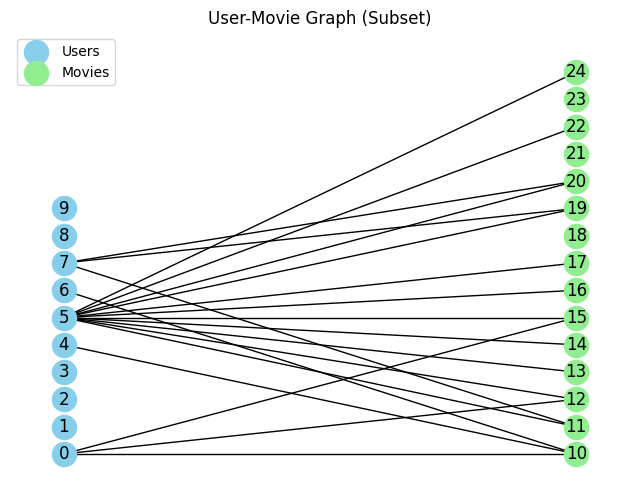

In [66]:
import networkx as nx
import matplotlib.pyplot as plt

# Take a SMALL subset for visualization
num_users = 10
num_movies = 15

edge_index = data["user", "rates", "movie"].edge_index

# Filter edges to small subset
edges = []
for u, m in zip(edge_index[0], edge_index[1]):
    if u < num_users and m < num_movies:
        edges.append((int(u), int(m)))

# Create graph
G = nx.Graph()

# Add user nodes
for u in range(num_users):
    G.add_node(u, node_type='user')

# Add movie nodes (offset)
movie_offset = num_users
for m in range(num_movies):
    G.add_node(m + movie_offset, node_type='movie')

# Add edges
for u, m in edges:
    G.add_edge(u, m + movie_offset)

# Position nodes
pos = {}

# Users (left)
for u in range(num_users):
    pos[u] = (0, u)

# Movies (right)
for m in range(num_movies):
    pos[m + movie_offset] = (1, m)

# Separate nodes
user_nodes = [n for n in G.nodes if n < movie_offset]
movie_nodes = [n for n in G.nodes if n >= movie_offset]

# Plot
plt.figure(figsize=(8,6))

nx.draw_networkx_nodes(G, pos, nodelist=user_nodes, node_color='skyblue', label='Users')
nx.draw_networkx_nodes(G, pos, nodelist=movie_nodes, node_color='lightgreen', label='Movies')

nx.draw_networkx_edges(G, pos)
nx.draw_networkx_labels(G, pos)

plt.title("User-Movie Graph (Subset)")
plt.legend()
plt.axis('off')
plt.show()

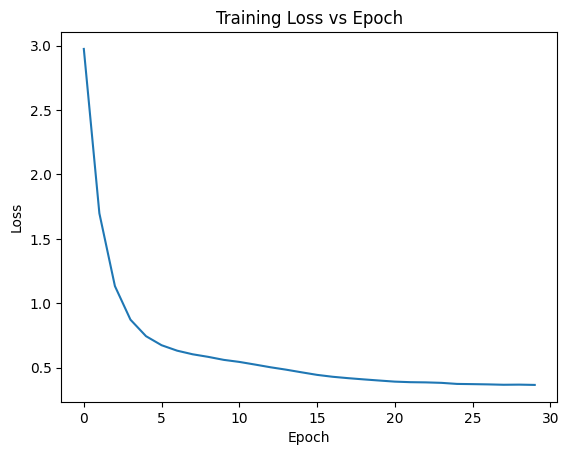

In [73]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss vs Epoch")
plt.show()

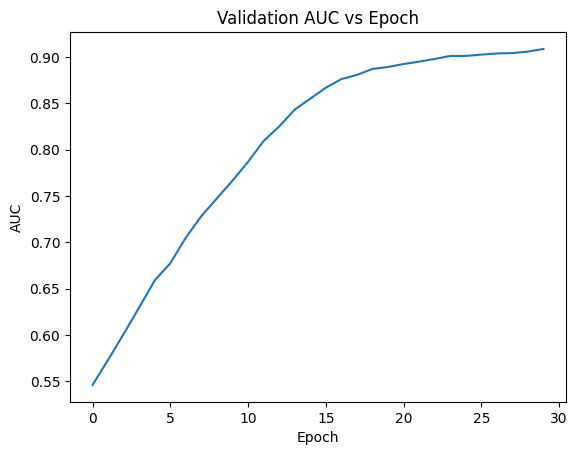

In [74]:
plt.figure()
plt.plot(val_aucs)
plt.xlabel("Epoch")
plt.ylabel("AUC")
plt.title("Validation AUC vs Epoch")
plt.show()

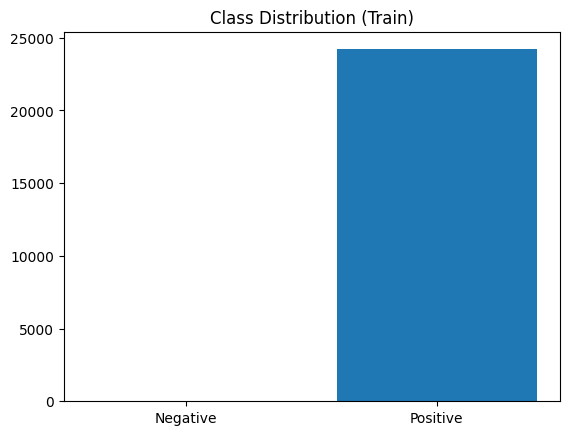

In [75]:
import numpy as np

labels = train_data["user", "rates", "movie"].edge_label.cpu().numpy()

counts = np.bincount(labels.astype(int))

plt.figure()
plt.bar(["Negative", "Positive"], counts)
plt.title("Class Distribution (Train)")
plt.show()

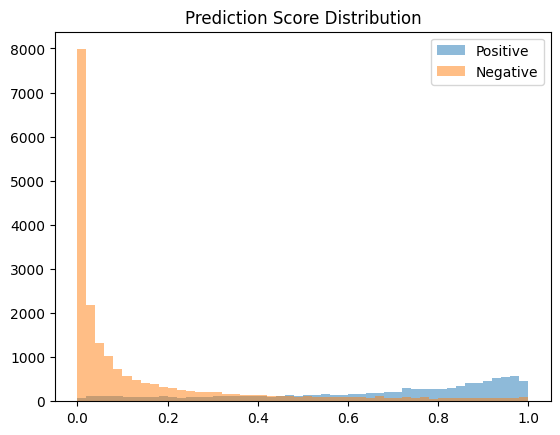

In [78]:
plt.figure()

pos_scores = pred_all[gt_all == 1]
neg_scores = pred_all[gt_all == 0]

plt.hist(pos_scores, bins=50, alpha=0.5, label="Positive")
plt.hist(neg_scores, bins=50, alpha=0.5, label="Negative")

plt.legend()
plt.title("Prediction Score Distribution")
plt.show()